In [2]:
import os

# Step up to project root so all paths still work
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: /Users/jamespham/PycharmProjects/ekg_analyzer


In [1]:
import sys
!{sys.executable} -m pip install wfdb neurokit2 torch matplotlib numpy plotly

import wfdb
import numpy as np
import torch
import torch.nn as nn
import neurokit2 as nk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from collections import Counter
import pickle

%matplotlib inline

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [11]:
# Rebuild the model architecture
class ECG_CNN(nn.Module):
    def __init__(self, num_classes):
        super(ECG_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 54, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Load everything from the single checkpoint
checkpoint  = torch.load('./models/ecg_cnn.pth', 
                         map_location=device, 
                         weights_only=False)
num_classes = checkpoint['num_classes']
class_names = checkpoint['encoder_classes']

model = ECG_CNN(num_classes).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Classes:", class_names)
print("Model loaded successfully")

Classes: ['Fusion', 'Normal', 'PAC', 'PVC', 'Paced']
Model loaded successfully


In [12]:
# Color for each predicted class — mirrors clinical convention
# red = dangerous, orange = moderate concern, blue = informational
condition_colors = {
    'Normal':  '#2ecc71',   # green  — no concern
    'PVC':     '#e74c3c',   # red    — high concern
    'PAC':     '#e67e22',   # orange — moderate concern
    'Fusion':  '#9b59b6',   # purple — moderate concern
    'Paced':   '#3498db',   # blue   — informational
    'Unknown': '#95a5a6',   # gray   — uncertain
}

condition_labels = {
    'Normal':  'Normal beat',
    'PVC':     'PVC — Premature Ventricular Contraction',
    'PAC':     'PAC — Premature Atrial Contraction',
    'Fusion':  'Fusion beat',
    'Paced':   'Paced beat',
    'Unknown': 'Unknown',
}

print("Color scheme defined.")

Color scheme defined.


In [13]:
def predict_beats(signal, r_peaks, fs, model, class_names, device):
    """
    Run CNN inference on every detected beat in a signal.
    
    Returns a list of dicts, one per beat:
        sample_start  — start sample of the beat window
        sample_end    — end sample of the beat window  
        r_peak        — sample index of the R-peak
        prediction    — predicted class name
        confidence    — confidence score (0-1)
        all_probs     — probability for every class
    """
    pre  = int(0.2 * fs)
    post = int(0.4 * fs)

    results = []

    for peak in r_peaks:
        # Skip beats too close to signal edges
        if peak - pre < 0 or peak + post >= len(signal):
            continue

        # Extract and normalize the beat window
        beat   = signal[peak - pre : peak + post]
        mean   = beat.mean()
        std    = beat.std() + 1e-8
        beat   = (beat - mean) / std

        # Reshape for model: (1, 1, 216)
        tensor = torch.FloatTensor(beat).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            output     = model(tensor)
            probs      = torch.softmax(output, dim=1).cpu().numpy()[0]
            pred_idx   = probs.argmax()
            confidence = probs[pred_idx]
            prediction = class_names[pred_idx]

        results.append({
            'sample_start': peak - pre,
            'sample_end':   peak + post,
            'r_peak':       peak,
            'prediction':   prediction,
            'confidence':   confidence,
            'all_probs':    dict(zip(class_names, probs))
        })

    return results

In [15]:
# Load a record known to have arrhythmias
rec_id = '119'    # good mix of PVCs and normal beats

record      = wfdb.rdrecord(f'./data/mitdb/{rec_id}')
annotations = wfdb.rdann(f'./data/mitdb/{rec_id}', 'atr')

fs     = record.fs
signal = record.p_signal[:, 0]

# Clean and detect R-peaks
cleaned    = nk.ecg_clean(signal, sampling_rate=fs)
peaks_dict = nk.ecg_peaks(cleaned, sampling_rate=fs)
r_peaks    = peaks_dict[1]['ECG_R_Peaks']

print(f"Record {rec_id} loaded")
print(f"Duration: {len(signal)/fs/60:.1f} minutes")
print(f"R-peaks detected: {len(r_peaks)}")

# Run inference on every beat
results = predict_beats(cleaned, r_peaks, fs, model, class_names, device)

# Summarize predictions
pred_counts = Counter(r['prediction'] for r in results)
print("\nPrediction summary:")
for cls, count in pred_counts.most_common():
    pct = count / len(results) * 100
    print(f"  {cls:10s}: {count:4d} beats ({pct:.1f}%)")

Record 119 loaded
Duration: 30.1 minutes
R-peaks detected: 1988

Prediction summary:
  Normal    : 1543 beats (77.7%)
  PVC       :  444 beats (22.3%)


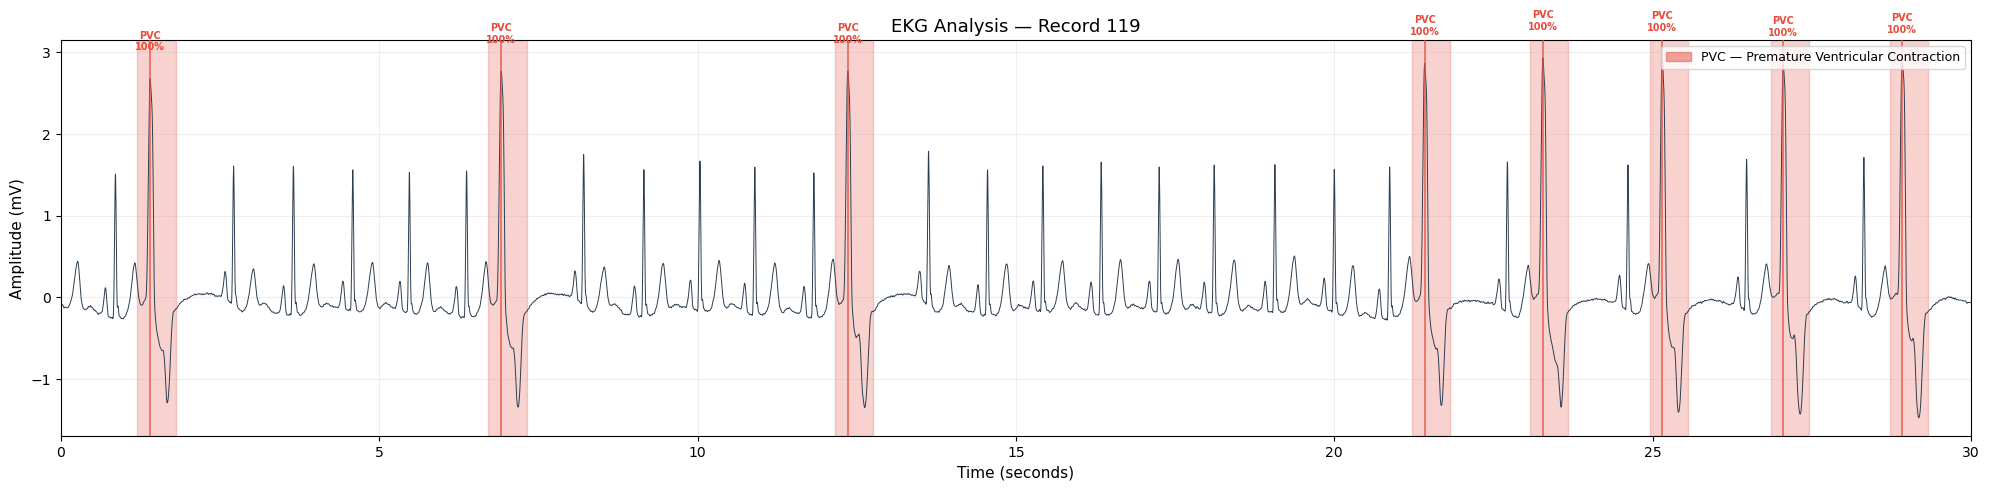

In [16]:
def plot_highlighted_ecg(signal, results, fs, 
                         start_sec=0, duration_sec=30,
                         condition_colors=condition_colors,
                         condition_labels=condition_labels,
                         confidence_threshold=0.7,
                         title="EKG Analysis"):
    
    start_sample = int(start_sec * fs)
    end_sample   = int((start_sec + duration_sec) * fs)
    time         = np.arange(start_sample, end_sample) / fs

    fig, ax = plt.subplots(figsize=(20, 5))

    # Plot the ECG signal
    ax.plot(time, signal[start_sample:end_sample],
            color='#2c3e50', linewidth=0.7, zorder=2)

    # Track which classes appear in this window for the legend
    legend_classes = set()

    for r in results:
        # Only highlight beats in the visible window
        if r['sample_end'] < start_sample or r['sample_start'] > end_sample:
            continue
        # Skip low-confidence predictions
        if r['confidence'] < confidence_threshold:
            continue
        # Skip normal beats — no highlighting needed
        if r['prediction'] == 'Normal':
            continue

        color      = condition_colors.get(r['prediction'], '#95a5a6')
        beat_start = r['sample_start'] / fs
        beat_end   = r['sample_end']   / fs

        # Shaded region
        ax.axvspan(beat_start, beat_end,
                   alpha=0.25, color=color, zorder=1)

        # Vertical line at R-peak
        ax.axvline(r['r_peak'] / fs,
                   color=color, linewidth=1.2,
                   alpha=0.8, zorder=3)

        # Label above the beat
        label_x = r['r_peak'] / fs
        label_y = signal[r['r_peak']] + 0.35
        ax.text(label_x, label_y,
                f"{r['prediction']}\n{r['confidence']:.0%}",
                fontsize=7, ha='center', color=color,
                fontweight='bold', zorder=4)

        legend_classes.add(r['prediction'])

    # Build legend from classes that actually appear
    patches = []
    for cls in legend_classes:
        color = condition_colors.get(cls, '#95a5a6')
        label = condition_labels.get(cls, cls)
        patches.append(mpatches.Patch(color=color, alpha=0.5, label=label))

    if patches:
        ax.legend(handles=patches, loc='upper right', fontsize=9)

    ax.set_xlabel("Time (seconds)", fontsize=11)
    ax.set_ylabel("Amplitude (mV)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(start_sec, start_sec + duration_sec)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# Plot the first 30 seconds
plot_highlighted_ecg(
    signal   = cleaned,
    results  = results,
    fs       = fs,
    start_sec = 0,
    duration_sec = 30,
    title    = f"EKG Analysis — Record {rec_id}"
)

Version for us in the Streamlit app — supports zoom, pan, and hover tooltips

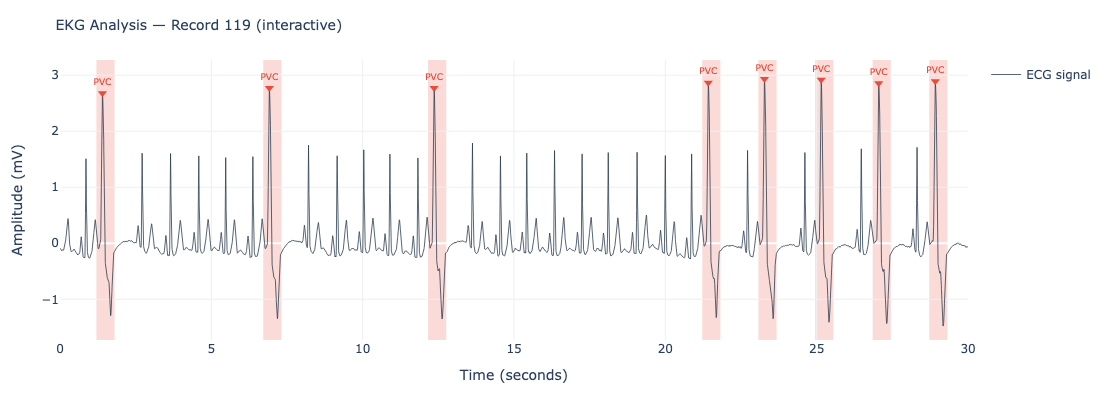

In [17]:
def plot_interactive_ecg(signal, results, fs,
                         start_sec=0, duration_sec=30,
                         condition_colors=condition_colors,
                         condition_labels=condition_labels,
                         confidence_threshold=0.7,
                         title="EKG Analysis"):

    start_sample = int(start_sec * fs)
    end_sample   = int((start_sec + duration_sec) * fs)
    time         = np.arange(start_sample, end_sample) / fs

    fig = go.Figure()

    # Main ECG trace
    fig.add_trace(go.Scatter(
        x=time,
        y=signal[start_sample:end_sample],
        mode='lines',
        line=dict(color='#2c3e50', width=0.8),
        name='ECG signal',
        hoverinfo='skip'
    ))

    # Add a highlighted region and marker for each abnormal beat
    for r in results:
        if r['sample_end'] < start_sample or r['sample_start'] > end_sample:
            continue
        if r['confidence'] < confidence_threshold:
            continue
        if r['prediction'] == 'Normal':
            continue

        color     = condition_colors.get(r['prediction'], '#95a5a6')
        full_name = condition_labels.get(r['prediction'], r['prediction'])

        # Shaded region
        fig.add_vrect(
            x0=r['sample_start'] / fs,
            x1=r['sample_end']   / fs,
            fillcolor=color,
            opacity=0.2,
            layer='below',
            line_width=0,
        )

        # Marker at R-peak with hover tooltip
        fig.add_trace(go.Scatter(
            x=[r['r_peak'] / fs],
            y=[signal[r['r_peak']]],
            mode='markers+text',
            marker=dict(color=color, size=8, symbol='triangle-down'),
            text=[r['prediction']],
            textposition='top center',
            textfont=dict(size=9, color=color),
            name=full_name,
            hovertemplate=(
                f"<b>{full_name}</b><br>"
                f"Time: %{{x:.2f}}s<br>"
                f"Confidence: {r['confidence']:.0%}<br>"
                "<extra></extra>"
            ),
            showlegend=False
        ))

    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        xaxis_title="Time (seconds)",
        yaxis_title="Amplitude (mV)",
        hovermode='x unified',
        height=400,
        margin=dict(l=60, r=20, t=60, b=60),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            range=[start_sec, start_sec + duration_sec],
            gridcolor='#ecf0f1'
        ),
        yaxis=dict(gridcolor='#ecf0f1')
    )

    fig.show()


# Interactive plot of the first 30 seconds
plot_interactive_ecg(
    signal       = cleaned,
    results      = results,
    fs           = fs,
    start_sec    = 0,
    duration_sec = 30,
    title        = f"EKG Analysis — Record {rec_id} (interactive)"
)

In [18]:
# Build a clean summary table of all flagged beats
flagged = [r for r in results 
           if r['prediction'] != 'Normal' 
           and r['confidence'] >= 0.7]

rows = []
for r in flagged:
    time_sec = r['r_peak'] / fs
    rows.append({
        'Time (s)':   f"{time_sec:.2f}",
        'Time (m:s)': f"{int(time_sec//60)}:{int(time_sec%60):02d}",
        'Condition':  condition_labels.get(r['prediction'], r['prediction']),
        'Confidence': f"{r['confidence']:.0%}",
    })

import pandas as pd
df = pd.DataFrame(rows)

print(f"Total beats analyzed: {len(results)}")
print(f"Flagged for review:   {len(flagged)} "
      f"({len(flagged)/len(results)*100:.1f}%)\n")
print(df.to_string(index=False))

Total beats analyzed: 1987
Flagged for review:   444 (22.3%)

Time (s) Time (m:s)                               Condition Confidence
    1.40       0:01 PVC — Premature Ventricular Contraction       100%
    6.92       0:06 PVC — Premature Ventricular Contraction       100%
   12.36       0:12 PVC — Premature Ventricular Contraction       100%
   21.42       0:21 PVC — Premature Ventricular Contraction       100%
   23.27       0:23 PVC — Premature Ventricular Contraction       100%
   25.15       0:25 PVC — Premature Ventricular Contraction       100%
   27.05       0:27 PVC — Premature Ventricular Contraction       100%
   28.92       0:28 PVC — Premature Ventricular Contraction       100%
   30.74       0:30 PVC — Premature Ventricular Contraction       100%
   36.11       0:36 PVC — Premature Ventricular Contraction       100%
   37.94       0:37 PVC — Premature Ventricular Contraction       100%
   39.80       0:39 PVC — Premature Ventricular Contraction       100%
   41.62       

In [19]:
import os
os.makedirs('./data/outputs', exist_ok=True)

# Save results for this record
np.save(f'./data/outputs/results_{rec_id}.npy', results)
df.to_csv(f'./data/outputs/flagged_{rec_id}.csv', index=False)

print(f"Saved results and flagged beats table for record {rec_id}")

Saved results and flagged beats table for record 119


In [4]:
import wfdb
import neurokit2 as nk
import numpy as np

record      = wfdb.rdrecord('./data/mitdb/208')
annotations = wfdb.rdann('./data/mitdb/208', 'atr')

fs     = record.fs
signal = record.p_signal[:, 0]

print("Signal shape:", signal.shape)
print("Sampling rate:", fs)
print("NaN values in signal:", np.isnan(signal).sum())
print("Inf values in signal:", np.isinf(signal).sum())

# Try cleaning
cleaned = nk.ecg_clean(signal, sampling_rate=fs)
print("Cleaning succeeded")

# Try peak detection
peaks_dict = nk.ecg_peaks(cleaned, sampling_rate=fs)
r_peaks    = peaks_dict[1]['ECG_R_Peaks']
print("R-peaks detected:", len(r_peaks))

Signal shape: (650000,)
Sampling rate: 360
NaN values in signal: 0
Inf values in signal: 0
Cleaning succeeded
R-peaks detected: 2949
